In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


In [ ]:
data_dir = "/content/drive/MyDrive/Images DataBase/Images DataBase"
img_size = (224, 224)
batch_size = 32

dataset = image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = dataset.class_names
num_classes = len(class_names)
print("Classes:", num_classes)

X_raw, y = [], []

for imgs, labels in dataset:
    X_raw.append(imgs.numpy())
    y.append(labels.numpy())

X_raw = np.vstack(X_raw).astype(np.float32)
y = np.hstack(y)

print("Images:", X_raw.shape)
print("Labels:", y.shape)


Found 1710 files belonging to 30 classes.
Classes: 30
Images: (1710, 224, 224, 3)
Labels: (1710,)


In [ ]:
base_model = DenseNet201(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224,224,3)
)

feature_model = Model(base_model.input, base_model.output)

X_features = feature_model.predict(
    preprocess_input(X_raw),
    batch_size=32,
    verbose=1
)

print("Feature shape:", X_features.shape)


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 67s 654ms/step
Feature shape: (1710, 1920)


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
def build_softmax_head(input_dim, num_classes):
    model = Sequential([
        Dense(512, activation='relu', input_shape=(input_dim,)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model


softmax_acc = []

print("\n===== DenseNet201 Features + Softmax (Baseline) =====")

for fold, (train_idx, test_idx) in enumerate(skf.split(X_features, y), 1):

    model = build_softmax_head(X_features.shape[1], num_classes)
    model.compile(
        optimizer=Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_features[train_idx],
        y[train_idx],
        epochs=30,
        batch_size=32,
        verbose=0
    )

    _, acc = model.evaluate(
        X_features[test_idx],
        y[test_idx],
        verbose=0
    )

    softmax_acc.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

print("Softmax Mean Accuracy:", np.mean(softmax_acc))



===== DenseNet201 Features + Softmax (Baseline) =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Accuracy: 0.8392
Fold 2 Accuracy: 0.8363
Fold 3 Accuracy: 0.8129
Fold 4 Accuracy: 0.8363
Fold 5 Accuracy: 0.7602
Softmax Mean Accuracy: 0.8169590830802917


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import ttest_ind

# ============================================================
# 1. SUBJECT-WISE INTRA / INTER DISTANCE ANALYSIS
# ============================================================

subject_stats = []
all_intra = []
all_inter = []

unique_subjects = np.unique(y)

for subj in unique_subjects:
    idx_same = np.where(y == subj)[0]
    idx_diff = np.where(y != subj)[0]

    # Safety check
    if len(idx_same) < 2:
        continue

    # Intra-subject distances
    intra = cosine_distances(
        X_features[idx_same],
        X_features[idx_same]
    )
    intra_vals = intra[np.triu_indices(len(idx_same), k=1)]

    # Inter-subject distances
    inter_vals = cosine_distances(
        X_features[idx_same],
        X_features[idx_diff]
    ).flatten()

    # Store for global analysis
    all_intra.extend(intra_vals)
    all_inter.extend(inter_vals)

    # Store subject-wise stats
    subject_stats.append({
        "Subject": int(subj),
        "Num_samples": len(idx_same),
        "Intra_mean": float(intra_vals.mean()),
        "Inter_mean": float(inter_vals.mean()),
        "Ratio": float(inter_vals.mean() / intra_vals.mean())
    })

df_stats = pd.DataFrame(subject_stats)

# ============================================================
# 2. REPORT SUBJECT-WISE RESULTS
# ============================================================

print("Subjects evaluated:", len(df_stats))
print("Subjects with Inter > Intra:",
      np.sum(df_stats["Ratio"] > 1),
      "/", len(df_stats))

print("\nMean separability ratio:",
      df_stats["Ratio"].mean())

df_stats

Subjects evaluated: 30
Subjects with Inter > Intra: 30 / 30

Mean separability ratio: 1.5027402798334757


,Subject,Num_samples,Intra_mean,Inter_mean,Ratio
0,0,55,0.146576,0.231972,1.582608
1,1,59,0.179529,0.233519,1.300734
2,2,58,0.149913,0.236468,1.577361
3,3,58,0.141217,0.221018,1.565100
4,4,60,0.158371,0.235509,1.487070
5,5,60,0.125824,0.215068,1.709272
6,6,60,0.202332,0.245504,1.213375
7,7,59,0.124620,0.213225,1.710999
8,8,56,0.127715,0.223355,1.748861
9,9,56,0.189153,0.247446,1.308178


In [ ]:
# ============================================================
# 3. GLOBAL STATISTICAL ANALYSIS (SUPPORTING EVIDENCE)
# ============================================================

all_intra = np.array(all_intra)
all_inter = np.array(all_inter)

print("\nGlobal Intra-subject distance:")
print(f"Mean = {all_intra.mean():.4f}, Std = {all_intra.std():.4f}")

print("\nGlobal Inter-subject distance:")
print(f"Mean = {all_inter.mean():.4f}, Std = {all_inter.std():.4f}")

print("\nSeparability Ratio (Inter / Intra):",
      all_inter.mean() / all_intra.mean())

# Welch's t-test
t_stat, p_val = ttest_ind(all_inter, all_intra, equal_var=False)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_val:.2e}")


Global Intra-subject distance:
Mean = 0.1618, Std = 0.0740

Global Inter-subject distance:
Mean = 0.2375, Std = 0.0751

Separability Ratio (Inter / Intra): 1.4677572
T-statistic: 222.38
P-value: 0.00e+00


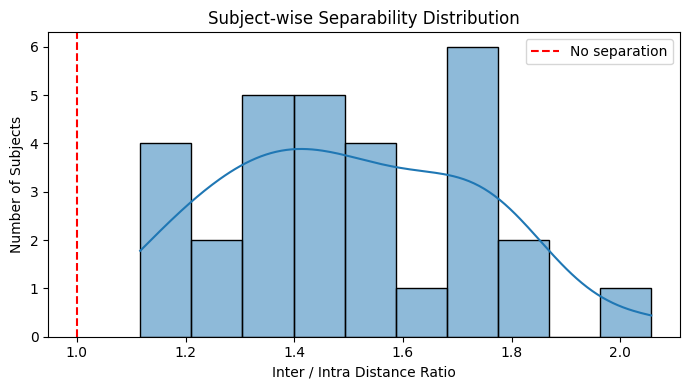

In [ ]:
# ============================================================
# 4. VISUALIZATION (KEEP ONE CLEAN FIGURE)
# ============================================================

plt.figure(figsize=(7,4))
sns.histplot(df_stats["Ratio"], bins=10, kde=True)
plt.axvline(1.0, color='red', linestyle='--', label='No separation')
plt.xlabel("Inter / Intra Distance Ratio")
plt.ylabel("Number of Subjects")
plt.title("Subject-wise Separability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
mean_diff = np.mean(all_inter) - np.mean(all_intra)
pooled_std = np.sqrt((np.var(all_inter) + np.var(all_intra)) / 2)
cohens_d = mean_diff / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: 1.0155622


In [ ]:
print("Ratio std:", df_stats["Ratio"].std())
print("Min ratio:", df_stats["Ratio"].min())
print("Max ratio:", df_stats["Ratio"].max())

Ratio std: 0.23545347746177742
Min ratio: 1.116542935371399
Max ratio: 2.0572335720062256


In [ ]:
df_stats.sort_values("Ratio").head(5)

,Subject,Num_samples,Intra_mean,Inter_mean,Ratio
18,18,59,0.210277,0.234783,1.116543
21,21,50,0.232398,0.265757,1.143540
22,22,60,0.202484,0.240408,1.187290
27,27,52,0.234484,0.280272,1.195273
6,6,60,0.202332,0.245504,1.213375


In [ ]:
from sklearn.metrics.pairwise import cosine_distances
from sklearn.model_selection import train_test_split

X_gallery, X_query = [], []
y_gallery, y_query = [], []

for subj in np.unique(y):
    idx = np.where(y == subj)[0]

    # Ensure at least 2 samples
    if len(idx) < 2:
        continue

    train_idx, test_idx = train_test_split(
        idx, test_size=0.3, random_state=42
    )

    X_gallery.append(X_features[train_idx])
    y_gallery.append(y[train_idx])

    X_query.append(X_features[test_idx])
    y_query.append(y[test_idx])

X_gallery = np.vstack(X_gallery)
y_gallery = np.hstack(y_gallery)

X_query = np.vstack(X_query)
y_query = np.hstack(y_query)

In [ ]:
correct = 0

for i in range(len(X_query)):
    dists = cosine_distances(
        X_query[i].reshape(1, -1),
        X_gallery
    ).flatten()

    nearest_idx = np.argmin(dists)

    if y_gallery[nearest_idx] == y_query[i]:
        correct += 1

rank1_accuracy = correct / len(X_query)

print(f"Rank-1 Identification Accuracy: {rank1_accuracy:.4f}")

Rank-1 Identification Accuracy: 0.7471


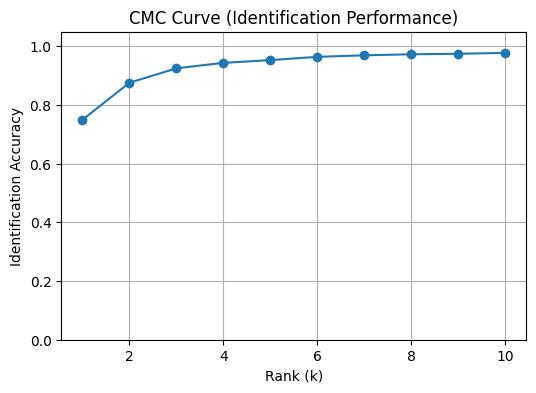

Rank-1 Accuracy: 0.7497
Rank-3 Accuracy: 0.9251
Rank-5 Accuracy: 0.9532


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances

# ============================================================
# CMC CURVE COMPUTATION
# ============================================================

def compute_cmc(X, y, max_rank=10):
    distances = cosine_distances(X, X)
    np.fill_diagonal(distances, np.inf)  # exclude self-match

    num_samples = X.shape[0]
    cmc_counts = np.zeros(max_rank)

    for i in range(num_samples):
        sorted_idx = np.argsort(distances[i])
        sorted_labels = y[sorted_idx]

        # first occurrence of correct subject
        rank = np.where(sorted_labels == y[i])[0][0]

        if rank < max_rank:
            cmc_counts[rank:] += 1

    cmc_curve = cmc_counts / num_samples
    return cmc_curve

# Compute CMC
max_rank = 10
cmc = compute_cmc(X_features, y, max_rank=max_rank)

# ============================================================
# PLOT CMC CURVE
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(range(1, max_rank + 1), cmc, marker='o')
plt.xlabel("Rank (k)")
plt.ylabel("Identification Accuracy")
plt.title("CMC Curve (Identification Performance)")
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()

# Print key ranks
for k in [1, 3, 5]:
    print(f"Rank-{k} Accuracy: {cmc[k-1]:.4f}")

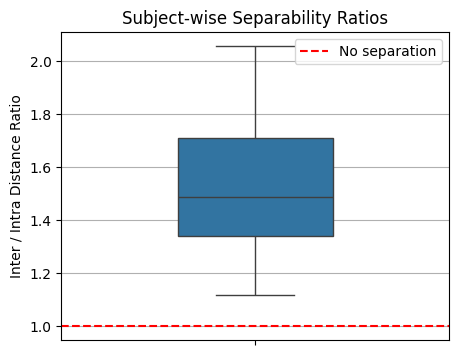

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# BOXPLOT OF SUBJECT-WISE RATIOS
# ============================================================

plt.figure(figsize=(5, 4))
sns.boxplot(
    y=df_stats["Ratio"],
    width=0.4
)

# Vertical reference line at no-separation
plt.axhline(1.0, color='red', linestyle='--', label='No separation')

plt.ylabel("Inter / Intra Distance Ratio")
plt.title("Subject-wise Separability Ratios")
plt.legend()
plt.grid(axis='y')
plt.show()

In [ ]:
#Pipeline Repetition for maintaining Order

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import ttest_ind

In [ ]:
subject_stats = []
all_intra, all_inter = [], []

for subj in np.unique(y):
    idx_same = np.where(y == subj)[0]
    idx_diff = np.where(y != subj)[0]

    if len(idx_same) < 2:
        continue

    intra = cosine_distances(X_features[idx_same], X_features[idx_same])
    intra_vals = intra[np.triu_indices(len(idx_same), k=1)]

    inter_vals = cosine_distances(
        X_features[idx_same],
        X_features[idx_diff]
    ).flatten()

    all_intra.extend(intra_vals)
    all_inter.extend(inter_vals)

    subject_stats.append({
        "Subject": int(subj),
        "Num_samples": len(idx_same),
        "Intra_mean": intra_vals.mean(),
        "Inter_mean": inter_vals.mean(),
        "Ratio": inter_vals.mean() / intra_vals.mean()
    })

df_stats = pd.DataFrame(subject_stats)

In [ ]:
all_intra = np.array(all_intra)
all_inter = np.array(all_inter)

print("Subjects evaluated:", len(df_stats))
print("Subjects with Inter > Intra:",
      (df_stats["Ratio"] > 1).sum(), "/", len(df_stats))

print("\nGlobal Intra: ", all_intra.mean())
print("Global Inter: ", all_inter.mean())
print("Separability Ratio:", all_inter.mean() / all_intra.mean())

t_stat, p_val = ttest_ind(all_inter, all_intra, equal_var=False)
print(f"T-statistic: {t_stat:.2f}, p-value: {p_val:.2e}")

# Cohen's d
cohens_d = (all_inter.mean() - all_intra.mean()) / np.sqrt(
    (all_inter.var() + all_intra.var()) / 2
)
print("Cohen's d:", cohens_d)

Subjects evaluated: 30
Subjects with Inter > Intra: 30 / 30

Global Intra:  0.16181009
Global Inter:  0.23749793
Separability Ratio: 1.4677572
T-statistic: 222.38, p-value: 0.00e+00
Cohen's d: 1.0155622


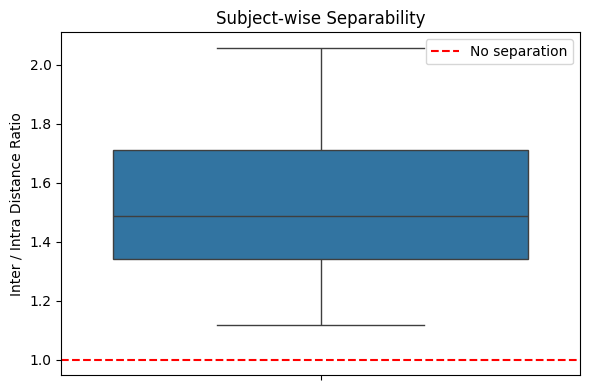

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_stats["Ratio"])
plt.axhline(1.0, color='red', linestyle='--', label='No separation')
plt.ylabel("Inter / Intra Distance Ratio")
plt.title("Subject-wise Separability")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_gallery, y_gallery = [], []
X_query, y_query = [], []

for subj in np.unique(y):
    idx = np.where(y == subj)[0]
    if len(idx) < 2:
        continue

    g_idx, q_idx = train_test_split(idx, test_size=0.3, random_state=42)

    X_gallery.append(X_features[g_idx])
    y_gallery.append(y[g_idx])

    X_query.append(X_features[q_idx])
    y_query.append(y[q_idx])

X_gallery = np.vstack(X_gallery)
y_gallery = np.hstack(y_gallery)
X_query = np.vstack(X_query)
y_query = np.hstack(y_query)

In [ ]:
correct = 0

for i in range(len(X_query)):
    dists = cosine_distances(
        X_query[i].reshape(1, -1),
        X_gallery
    ).flatten()

    if y_gallery[np.argmin(dists)] == y_query[i]:
        correct += 1

rank1_acc = correct / len(X_query)
print(f"Rank-1 Accuracy: {rank1_acc:.4f}")

Rank-1 Accuracy: 0.7471


In [ ]:
def compute_cmc_gallery_query(Xg, yg, Xq, yq, max_rank=10):
    cmc = np.zeros(max_rank)

    for i in range(len(Xq)):
        dists = cosine_distances(
            Xq[i].reshape(1, -1), Xg
        ).flatten()

        sorted_labels = yg[np.argsort(dists)]
        rank = np.where(sorted_labels == yq[i])[0][0]

        if rank < max_rank:
            cmc[rank:] += 1

    return cmc / len(Xq)

cmc = compute_cmc_gallery_query(
    X_gallery, y_gallery,
    X_query, y_query,
    max_rank=10
)

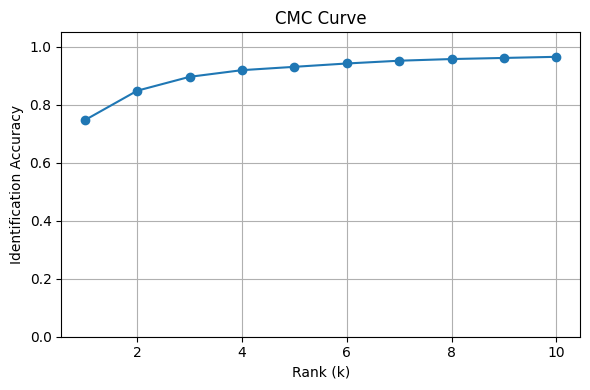

Rank-1 Accuracy: 0.7471
Rank-3 Accuracy: 0.8966
Rank-5 Accuracy: 0.9310


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(range(1,11), cmc, marker='o')
plt.xlabel("Rank (k)")
plt.ylabel("Identification Accuracy")
plt.title("CMC Curve")
plt.grid(True)
plt.ylim(0,1.05)
plt.tight_layout()
plt.show()

for k in [1,3,5]:
    print(f"Rank-{k} Accuracy: {cmc[k-1]:.4f}")